# 因子有效性分析

对每个因子独立检验截面预测力，不依赖任何策略假设。

**判断标准：**
- IC均值 > 0.03：有弱信号
- IC均值 > 0.05：有效因子
- ICIR > 0.5：信号稳定
- 分组单调性：Q5收益 > Q4 > ... > Q1（或反向单调）

In [ ]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import matplotlib
matplotlib.rcParams['font.family'] = 'SimHei'
matplotlib.rcParams['axes.unicode_minus'] = False

from config.settings import RAW_DIR, PROCESSED_DIR
from factors.factor import (
    # 价格因子
    factor_momentum, factor_reversal, factor_momentum_skip,
    factor_volatility, factor_turnover, factor_amihud,
    factor_price_to_high,
    # 财务因子
    factor_value_pb, factor_value_ep,
    factor_quality_roe, factor_quality_roe_chg,
    factor_quality_gpm, factor_quality_gpm_chg,
    factor_quality_accrual,
    factor_size, factor_leverage,
    # 工具
    cross_sectional_zscore, winsorize,
)

In [ ]:
prices    = pd.read_parquet(RAW_DIR / 'prices_hfq.parquet')
financial = pd.read_parquet(RAW_DIR / 'financial_indicators.parquet')

try:
    prices_raw = pd.read_parquet(RAW_DIR / 'prices_raw.parquet')
except FileNotFoundError:
    prices_raw = prices
    print('⚠️  未找到不复权价格，PB/EP因子用后复权代替（会有误差）')

# 成交量/成交额（部分因子需要）
try:
    volume = pd.read_parquet(RAW_DIR / 'volume.parquet')
    amount = pd.read_parquet(RAW_DIR / 'amount.parquet')
except FileNotFoundError:
    volume = None
    amount = None
    print('⚠️  未找到成交量/成交额数据，换手率/Amihud因子将跳过')

print(f'价格数据: {prices.shape}, {prices.index[0].date()} ~ {prices.index[-1].date()}')
print(f'财务数据: {financial.shape}')
print(f'成交量数据: {"✓" if volume is not None else "✗"}')

## 工具函数

In [3]:
def compute_ic_series(factor: pd.DataFrame, forward_return: pd.DataFrame) -> pd.Series:
    """每个截面日计算因子与下期收益的Spearman相关系数"""
    common_dates = factor.index.intersection(forward_return.index)
    ic = factor.loc[common_dates].corrwith(
        forward_return.loc[common_dates], axis=1, method='spearman'
    )
    return ic.dropna()


def ic_summary(ic: pd.Series, factor_name: str) -> dict:
    """计算IC统计量"""
    icir = ic.mean() / ic.std() if ic.std() > 0 else 0
    win_rate = (ic > 0).mean()
    return {
        'factor': factor_name,
        'IC均值': round(ic.mean(), 4),
        'IC标准差': round(ic.std(), 4),
        'ICIR': round(icir, 4),
        'IC>0胜率': round(win_rate, 4),
        'IC均值|abs|': round(ic.abs().mean(), 4),
    }


def plot_factor_analysis(factor: pd.DataFrame, forward_return: pd.DataFrame,
                         factor_name: str, n_groups: int = 5):
    """完整因子分析图：IC序列 + IC分布 + 分组净值 + 分组年化收益"""
    ic = compute_ic_series(factor, forward_return)
    stats = ic_summary(ic, factor_name)

    # ── 分组净值 ──
    rebalance_dates = sorted(factor.index.intersection(
        pd.date_range(factor.index[0], factor.index[-1], freq='ME')
    ))
    group_navs = {f'Q{g+1}': [1.0] for g in range(n_groups)}
    group_ann_rets = {f'Q{g+1}': [] for g in range(n_groups)}

    for i, date in enumerate(rebalance_dates[:-1]):
        next_date = rebalance_dates[i + 1]
        if date not in factor.index or next_date not in prices.index:
            for g in range(n_groups):
                group_navs[f'Q{g+1}'].append(group_navs[f'Q{g+1}'][-1])
            continue
        scores = factor.loc[date].dropna()
        if len(scores) < n_groups * 5:
            for g in range(n_groups):
                group_navs[f'Q{g+1}'].append(group_navs[f'Q{g+1}'][-1])
            continue
        for g in range(n_groups):
            lo, hi = g / n_groups, (g + 1) / n_groups
            codes = scores[
                (scores >= scores.quantile(lo)) & (scores < scores.quantile(hi))
            ].index.tolist()
            valid = [c for c in codes if c in prices.columns
                     and date in prices.index and next_date in prices.index]
            if not valid:
                group_navs[f'Q{g+1}'].append(group_navs[f'Q{g+1}'][-1])
                continue
            p0 = prices.loc[date, valid]
            p1 = prices.loc[next_date, valid]
            ret = (p1 / p0 - 1).mean()
            group_navs[f'Q{g+1}'].append(group_navs[f'Q{g+1}'][-1] * (1 + ret))
            group_ann_rets[f'Q{g+1}'].append(ret)

    nav_df = pd.DataFrame(group_navs, index=rebalance_dates[:len(group_navs['Q1'])])
    ann_ret = {k: (np.mean(v) * 12) for k, v in group_ann_rets.items() if v}

    # ── 画图 ──
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f'{factor_name}  因子分析', fontsize=14, fontweight='bold')
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

    # 1. IC序列
    ax1 = fig.add_subplot(gs[0, :])
    ic.plot(ax=ax1, alpha=0.6, color='steelblue', label='IC')
    ic.rolling(12).mean().plot(ax=ax1, color='red', linewidth=1.5, label='12期滚动均值')
    ax1.axhline(0, color='black', linewidth=0.8)
    ax1.axhline(0.05, color='green', linewidth=0.8, linestyle='--', alpha=0.5)
    ax1.axhline(-0.05, color='green', linewidth=0.8, linestyle='--', alpha=0.5)
    ax1.set_title(
        f'IC序列   均值={stats["IC均值"]}  ICIR={stats["ICIR"]}  '
        f'胜率={stats["IC>0胜率"]:.1%}'
    )
    ax1.legend(fontsize=9)
    ax1.set_xlabel('')

    # 2. IC分布
    ax2 = fig.add_subplot(gs[1, 0])
    ic.hist(ax=ax2, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax2.axvline(ic.mean(), color='red', linewidth=1.5, label=f'均值={ic.mean():.3f}')
    ax2.axvline(0, color='black', linewidth=0.8)
    ax2.set_title('IC分布直方图')
    ax2.legend(fontsize=9)

    # 3. 分组净值
    ax3 = fig.add_subplot(gs[1, 1])
    colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, n_groups))
    for i, col in enumerate(nav_df.columns):
        nav_df[col].plot(ax=ax3, color=colors[i], label=col, linewidth=1.2)
    ax3.set_title('分组净值（Q1=低分组，Q5=高分组）')
    ax3.legend(fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()

    # 分组年化收益柱状图
    fig2, ax = plt.subplots(figsize=(7, 4))
    groups = list(ann_ret.keys())
    rets = [ann_ret[g] * 100 for g in groups]
    bar_colors = ['#d73027' if r < 0 else '#1a9850' for r in rets]
    ax.bar(groups, rets, color=bar_colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{factor_name}  分组年化收益率 (%)')
    ax.set_ylabel('%')
    for i, (g, r) in enumerate(zip(groups, rets)):
        ax.text(i, r + (0.5 if r >= 0 else -1.5), f'{r:.1f}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

    return stats

## 定义所有待测因子

在这里注册所有因子，后面统一跑分析。

In [ ]:
HOLD_PERIOD = 20  # 持仓期（交易日，约1个月）

# 下期收益（月度），用于所有因子IC计算
forward_return_1m = prices.pct_change(HOLD_PERIOD).shift(-HOLD_PERIOD)

# ══════════════════════════════════════════════════════════════
# 因子注册表：在这里添加/删除因子，后面统一批量分析
# 格式：{'因子名': DataFrame(index=日期, columns=股票, 值=标准化得分)}
# ══════════════════════════════════════════════════════════════

factor_registry = {}

# ── 价格/动量因子（只需价格数据，现在就能跑）──────────────────
factor_registry['动量_20d']    = factor_momentum(prices, window=20)
factor_registry['动量_60d']    = factor_momentum(prices, window=60)
factor_registry['动量_120d']   = factor_momentum(prices, window=120)
factor_registry['动量_skip']   = factor_momentum_skip(prices, 240, 20)   # 12-1月动量
factor_registry['反转_5d']     = factor_reversal(prices, window=5)
factor_registry['反转_20d']    = factor_reversal(prices, window=20)
factor_registry['波动率_20d']  = factor_volatility(prices, window=20)
factor_registry['波动率_60d']  = factor_volatility(prices, window=60)
factor_registry['52周新高']    = factor_price_to_high(prices, 52 * 5)

# ── 需要成交量/成交额（如未下载则跳过）─────────────────────────
if volume is not None:
    factor_registry['换手率_20d'] = factor_turnover(volume, window=20)
if amount is not None:
    factor_registry['Amihud_20d'] = factor_amihud(prices, amount, window=20)

# ── 财务因子（需要 financial 数据）──────────────────────────────
if financial is not None and not financial.empty:
    factor_registry['价值_PB']      = factor_value_pb(financial, prices_raw)
    factor_registry['价值_EP']      = factor_value_ep(financial, prices_raw)
    factor_registry['质量_ROE']     = factor_quality_roe(financial, prices)
    factor_registry['质量_ROE变化'] = factor_quality_roe_chg(financial, prices)
    factor_registry['规模']         = factor_size(financial, prices)
    factor_registry['杠杆']         = factor_leverage(financial, prices)

    gpm     = factor_quality_gpm(financial, prices)
    gpm_chg = factor_quality_gpm_chg(financial, prices)
    accrual = factor_quality_accrual(financial, prices)
    if gpm     is not None: factor_registry['质量_毛利率']     = gpm
    if gpm_chg is not None: factor_registry['质量_毛利率变化'] = gpm_chg
    if accrual is not None: factor_registry['质量_应计项目']   = accrual

# 过滤掉计算失败的
factor_registry = {k: v for k, v in factor_registry.items() if v is not None}

print(f'共 {len(factor_registry)} 个因子待检验：')
for name in factor_registry:
    print(f'  {name}')

## 批量IC分析汇总

In [5]:
# 先跑一遍所有因子的IC统计，汇总对比
all_stats = []
all_ic = {}

for name, factor in factor_registry.items():
    ic = compute_ic_series(factor, forward_return_1m)
    all_ic[name] = ic
    all_stats.append(ic_summary(ic, name))

summary_df = pd.DataFrame(all_stats).set_index('factor')

# 按IC均值绝对值排序
summary_df = summary_df.reindex(
    summary_df['IC均值|abs|'].sort_values(ascending=False).index
)

# 标记有效因子
def highlight(val, col):
    if col == 'IC均值|abs|':
        if abs(val) >= 0.05: return 'background-color: #c6efce'
        if abs(val) >= 0.03: return 'background-color: #ffeb9c'
        return 'background-color: #ffc7ce'
    if col == 'ICIR':
        if abs(val) >= 0.5: return 'background-color: #c6efce'
        if abs(val) >= 0.3: return 'background-color: #ffeb9c'
        return ''
    return ''

summary_df.style.apply(
    lambda col: [highlight(v, col.name) for v in col], axis=0
)

,IC均值,IC标准差,ICIR,IC>0胜率,IC均值|abs|
factor,,,,,
动量_60d,-0.063400,0.149900,-0.422800,0.333000,0.128000
动量_20d,-0.069000,0.144300,-0.478300,0.317000,0.122400
反转_20d,0.069000,0.144300,0.478300,0.683000,0.122400
反转_5d,0.034100,0.132200,0.258100,0.589400,0.102800


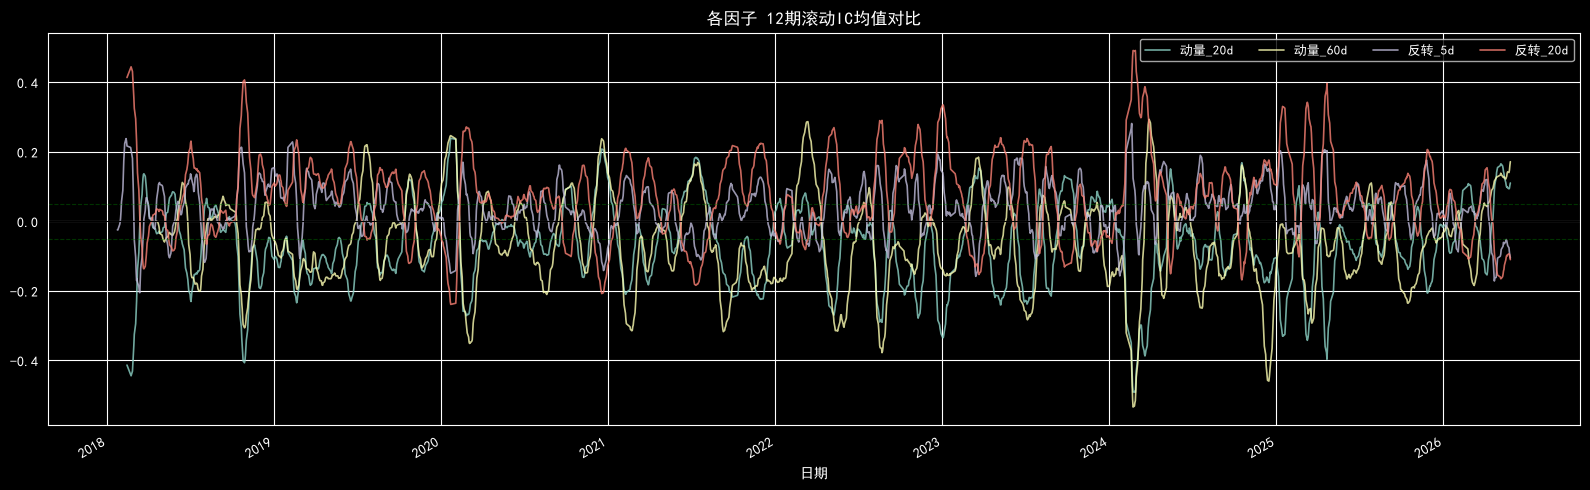

In [6]:
# IC序列对比图（所有因子的12期滚动IC均值）
fig, ax = plt.subplots(figsize=(16, 5))
for name, ic in all_ic.items():
    ic.rolling(12).mean().plot(ax=ax, label=name, alpha=0.8, linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.05, color='green', linewidth=0.8, linestyle='--', alpha=0.4)
ax.axhline(-0.05, color='green', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_title('各因子 12期滚动IC均值对比')
ax.legend(fontsize=9, ncol=4)
plt.tight_layout()
plt.show()

## 逐因子深度分析

对每个因子单独出图：IC序列、IC分布、分组净值、分组年化收益。

可以只跑汇总里IC均值 > 0.03 的因子。

进入深度分析的因子: ['动量_60d', '动量_20d', '反转_20d', '反转_5d']

因子：动量_60d


findfont: Failed to find font weight bold, now using 400.


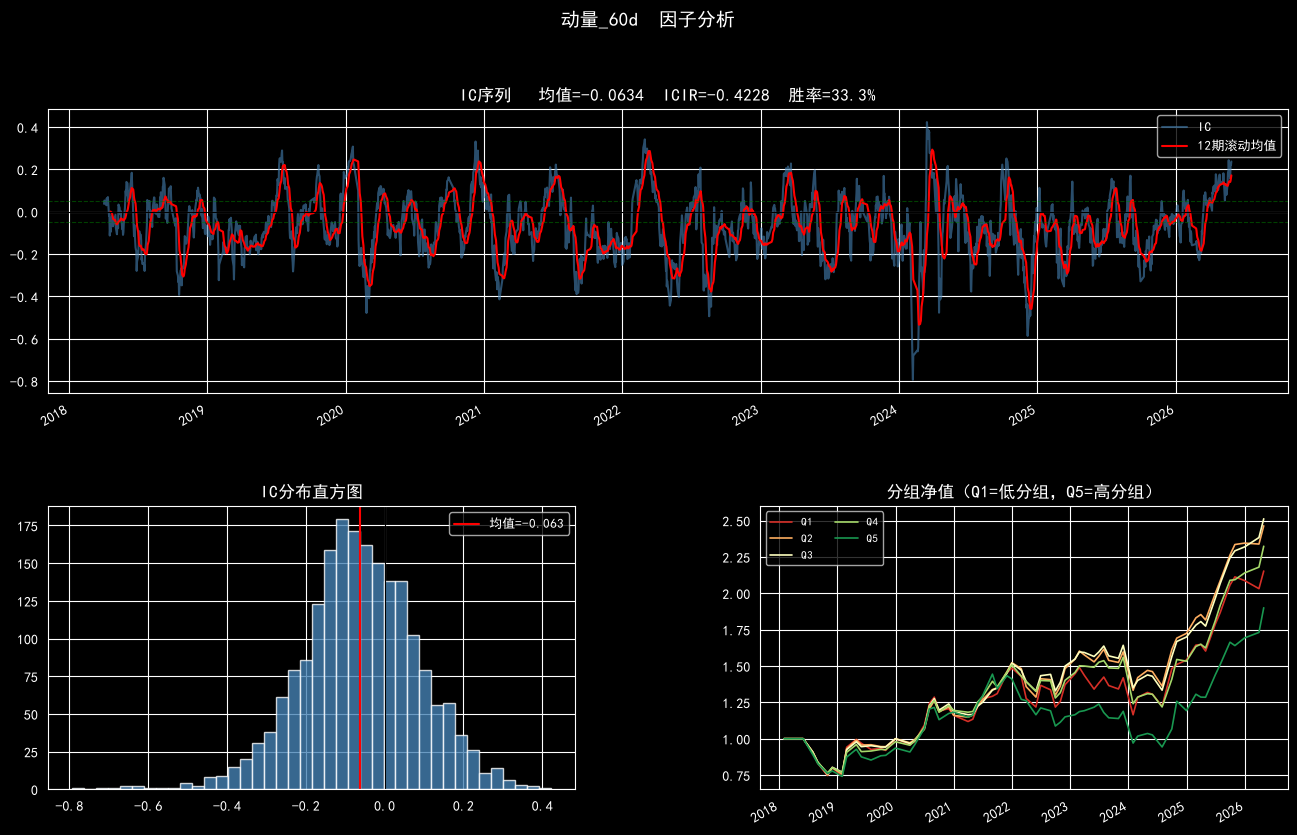

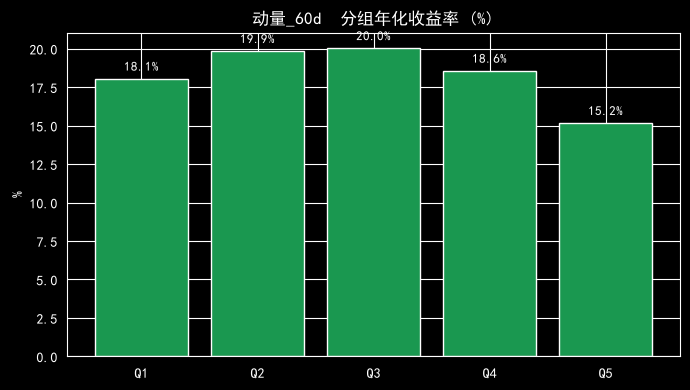


因子：动量_20d


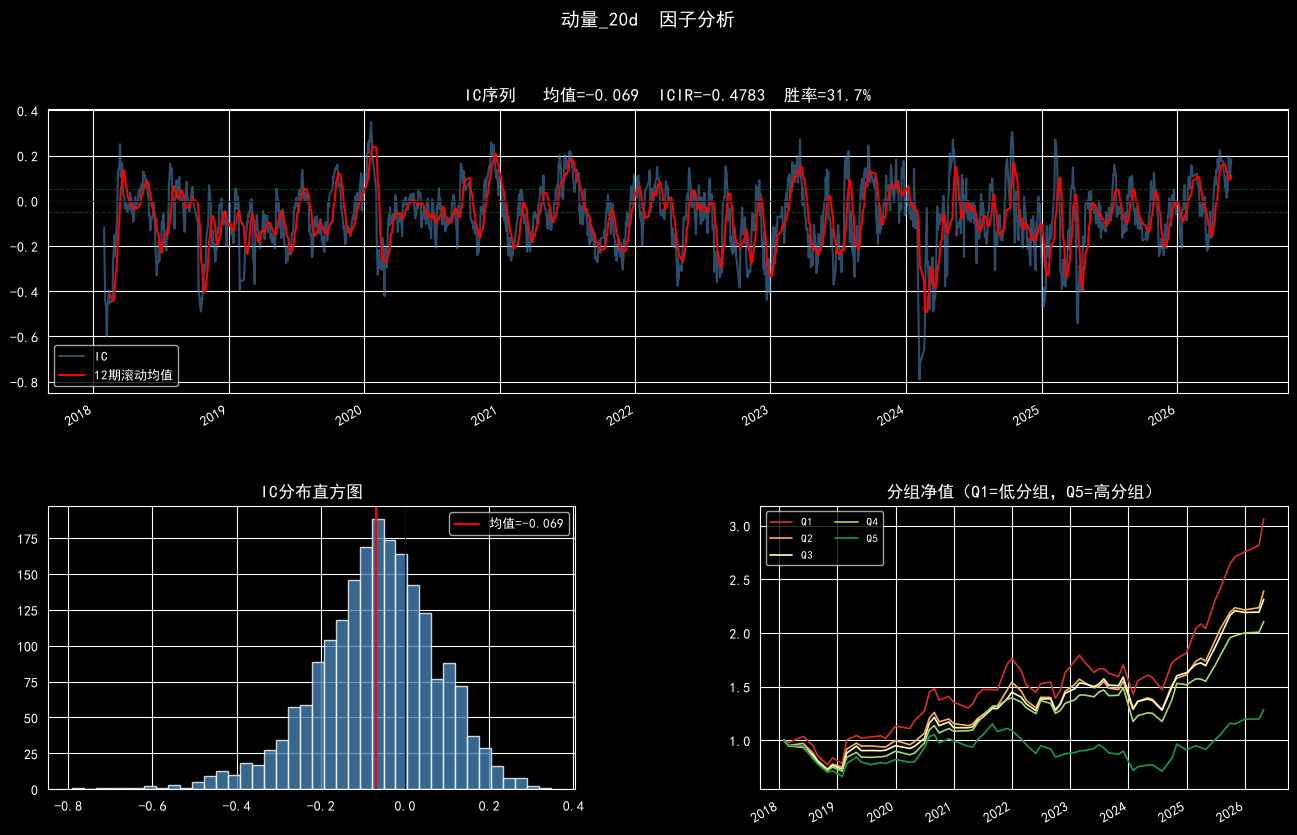

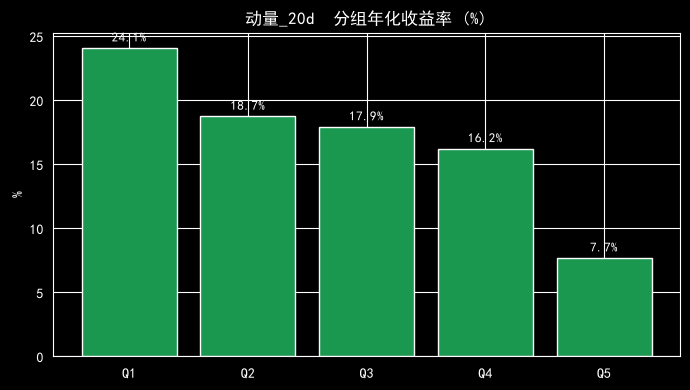


因子：反转_20d


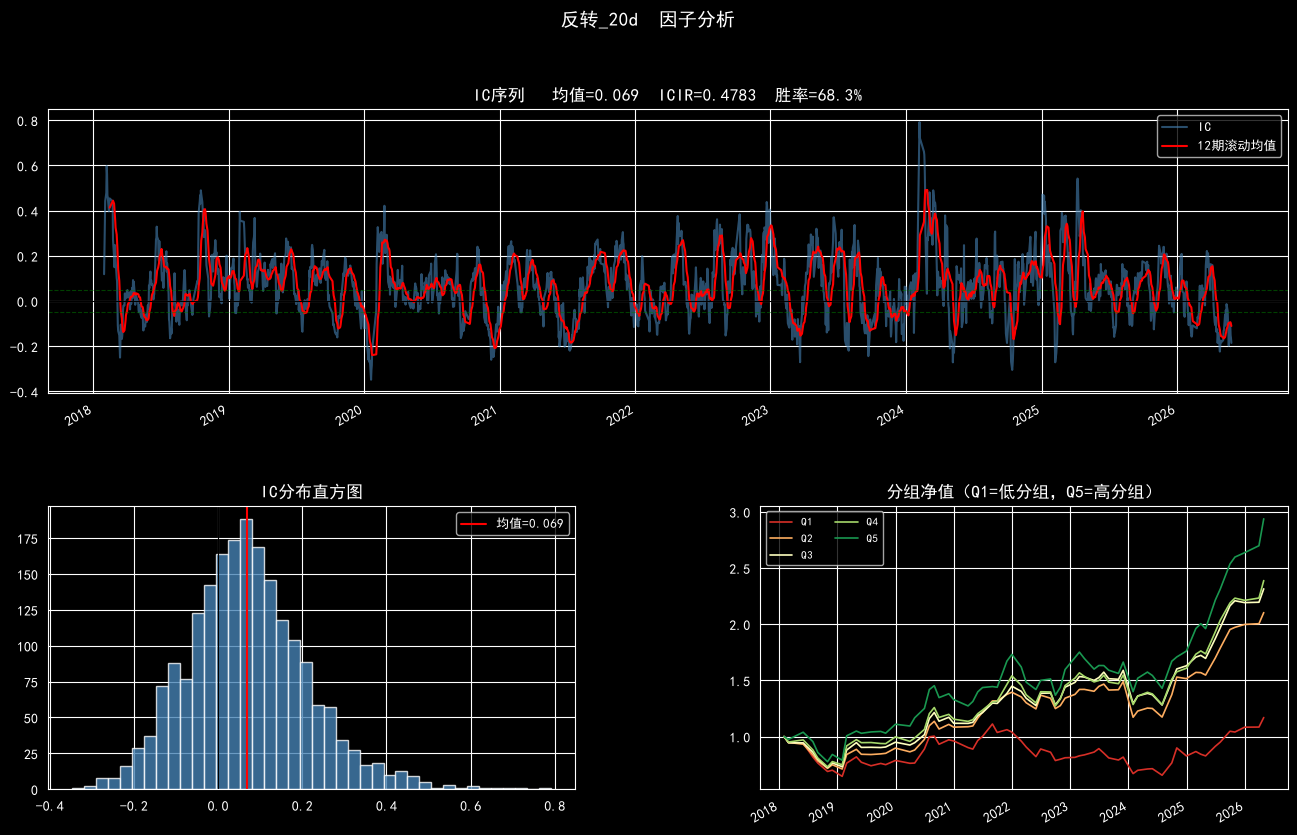

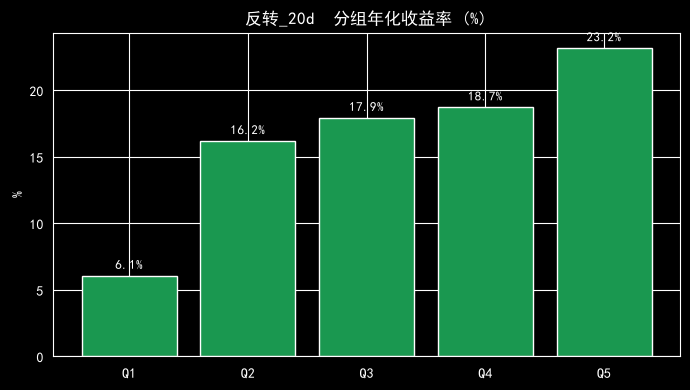


因子：反转_5d


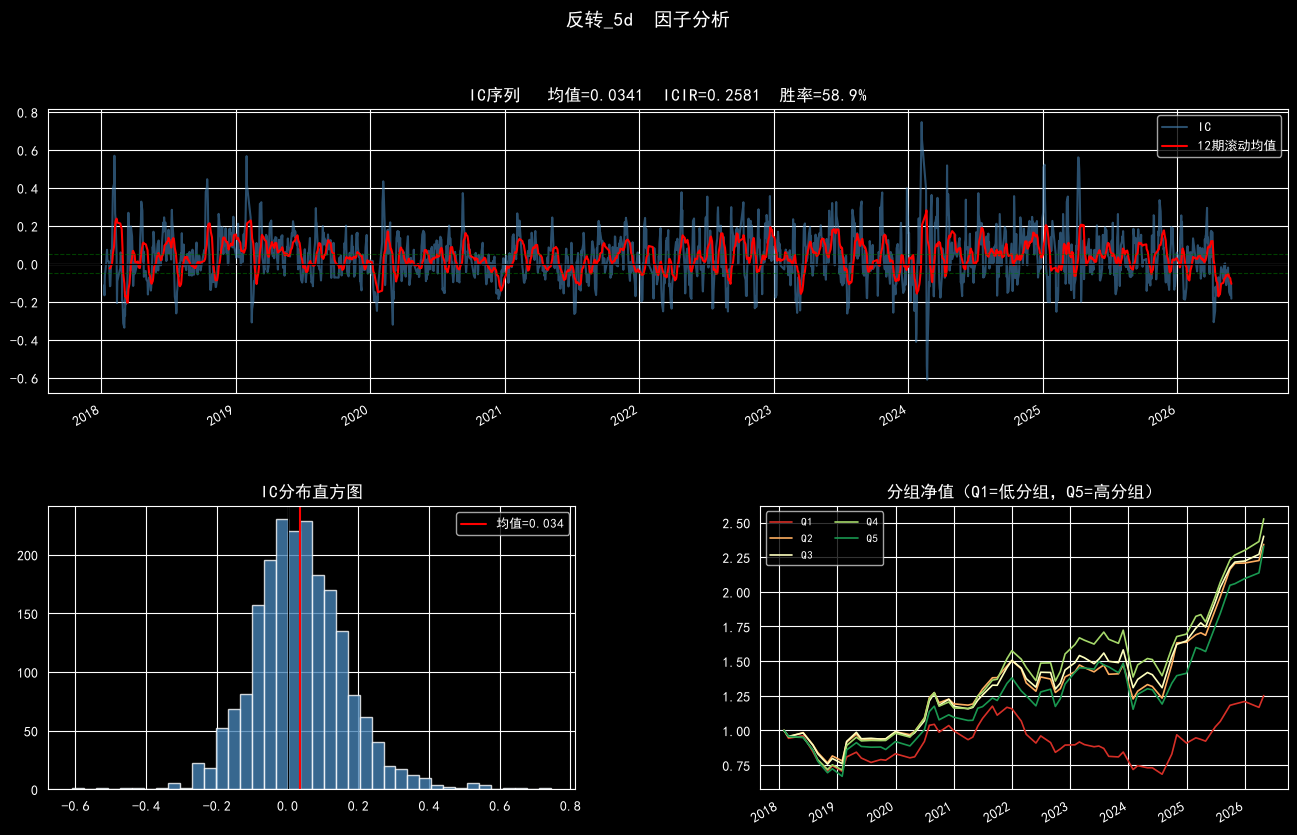

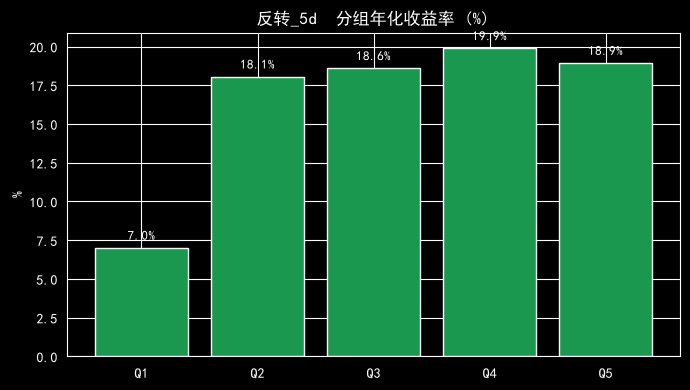

In [7]:
# 只对IC均值绝对值 > 0.03 的因子做深度分析
valid_factors = summary_df[summary_df['IC均值|abs|'] > 0.03].index.tolist()
print(f'进入深度分析的因子: {valid_factors}')

detailed_stats = []
for name in valid_factors:
    print(f'\n{"="*60}')
    print(f'因子：{name}')
    stats = plot_factor_analysis(
        factor_registry[name], forward_return_1m, name
    )
    detailed_stats.append(stats)

## 因子相关性矩阵

相关性 > 0.7 的因子对存在冗余，喂给 ML 时选其中一个即可。

In [ ]:
# 用某一天的截面因子值计算相关性（取中间时间段的均值）
sample_dates = prices.index[len(prices)//4 : 3*len(prices)//4 : 20]

corr_list = []
for date in sample_dates:
    row = {}
    for name, factor in factor_registry.items():
        if date in factor.index:
            row[name] = factor.loc[date]
    if len(row) == len(factor_registry):
        df_slice = pd.DataFrame(row).dropna()
        if len(df_slice) > 20:
            corr_list.append(df_slice.corr(method='spearman'))

if corr_list:
    avg_corr = pd.concat(corr_list).groupby(level=0).mean()
    
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(avg_corr, cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(avg_corr)))
    ax.set_yticks(range(len(avg_corr)))
    ax.set_xticklabels(avg_corr.columns, rotation=45, ha='right')
    ax.set_yticklabels(avg_corr.index)
    for i in range(len(avg_corr)):
        for j in range(len(avg_corr)):
            ax.text(j, i, f'{avg_corr.iloc[i,j]:.2f}',
                    ha='center', va='center', fontsize=8,
                    color='white' if abs(avg_corr.iloc[i,j]) > 0.5 else 'black')
    ax.set_title('因子截面相关性矩阵（Spearman，时序均值）')
    plt.tight_layout()
    plt.show()

    # 标记高相关对
    high_corr = []
    for i in range(len(avg_corr)):
        for j in range(i+1, len(avg_corr)):
            val = avg_corr.iloc[i, j]
            if abs(val) > 0.7:
                high_corr.append((avg_corr.index[i], avg_corr.columns[j], round(val, 3)))
    if high_corr:
        print('\n高相关因子对（|corr| > 0.7，存在冗余）：')
        for a, b, c in high_corr:
            print(f'  {a} vs {b}: {c}')
    else:
        print('无高相关因子对')

## IC衰减分析

验证因子预测力随持仓期延长的衰减速度。衰减快的因子适合短周期调仓，衰减慢的适合月度调仓。

In [ ]:
decay_periods = [5, 10, 20, 40, 60]  # 预测N日后收益的IC
decay_result = {}

for name in valid_factors:
    factor = factor_registry[name]
    ics = []
    for p in decay_periods:
        fwd = prices.pct_change(p).shift(-p)
        ic = compute_ic_series(factor, fwd).mean()
        ics.append(ic)
    decay_result[name] = ics

decay_df = pd.DataFrame(decay_result, index=decay_periods)

fig, ax = plt.subplots(figsize=(10, 5))
for col in decay_df.columns:
    ax.plot(decay_df.index, decay_df[col], marker='o', label=col, linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('持仓期（交易日）')
ax.set_ylabel('IC均值')
ax.set_title('因子IC衰减曲线')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\nIC衰减表：')
print(decay_df.round(4).to_string())